In [1]:
# import libraries
import pandas as pd
import numpy as np
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# load csv
macro = pd.read_csv("macro_daily_with_regimes.csv")
macro["session_date"] = pd.to_datetime(macro["session_date"]).dt.date

print(macro.shape)
print(macro.columns)

macro.head()

(2087, 31)
Index(['symbol', 'session_date', 'day_open', 'day_close', 'day_high',
       'day_low', 'day_volume', 'bars_in_day', 'daily_rv', 'daily_ret',
       'daily_abs_ret', 'daily_range_pct', 'daily_trend_strength', 'rv_3',
       'rv_long', 'rv_impulse', 'range_3', 'range_long', 'range_ratio',
       'trend_freq', 'sum_ret_3', 'sum_abs_ret_3', 'conditions_3', 'rel_vol',
       'rv_impulse_z', 'range_ratio_z', 'trend_freq_z', 'conditions_3_z',
       'rel_vol_z', 'regime_label', 'macro_regime_id'],
      dtype='str')


,symbol,session_date,day_open,day_close,day_high,day_low,day_volume,bars_in_day,daily_rv,daily_ret,...,sum_abs_ret_3,conditions_3,rel_vol,rv_impulse_z,range_ratio_z,trend_freq_z,conditions_3_z,rel_vol_z,regime_label,macro_regime_id
0,COIN,2024-04-11,250.99,263.07,264.3000,247.3103,7622950.0,78,0.004016,0.048129,...,0.111185,0.286362,-0.028097,1.187786,0.400600,1.384168,-0.774628,0.872453,Choppy,2
1,COIN,2024-04-12,259.42,245.79,259.9700,244.3101,7663576.0,78,0.004723,-0.052540,...,0.141572,0.439537,0.028618,-1.766660,1.733736,2.645558,-0.372099,1.153792,Range Bound,3
2,COIN,2024-04-15,247.94,223.36,249.7392,222.1400,9936693.0,78,0.004553,-0.099137,...,0.154439,0.319598,0.033933,-1.397150,1.683692,2.159545,-0.652874,1.143211,Range Bound,3
3,COIN,2024-04-16,223.00,218.84,223.0000,205.6700,14951181.0,78,0.006594,-0.018655,...,0.199807,0.518240,0.293688,-1.448819,2.488872,1.885512,0.021966,2.592548,Range Bound,3
4,COIN,2024-04-17,221.93,213.54,224.8700,205.9000,8495762.0,78,0.005566,-0.037805,...,0.170332,1.000000,0.701108,1.673873,2.105821,0.582311,1.465727,4.120425,Trending,1


In [3]:
# define features
macro_feature_cols = [
    "rv_impulse","range_ratio","trend_freq","conditions_3","rel_vol",
    "daily_rv","daily_range_pct","day_volume","daily_ret","daily_abs_ret","daily_trend_strength"
]

REGIME_INT    = {0: "Flat", 1: "Trending", 2: "Choppy", 3: "Range Bound"}
target_col    = "macro_regime_id"

print(macro.shape)
print(macro["regime_label"].value_counts())

(2087, 31)
regime_label
Range Bound    891
Trending       726
Choppy         339
Flat           131
Name: count, dtype: int64


In [4]:
# target column
# regime id (0=Flat, 1=Trending, 2=Choppy, 3=Range Bound)
target_col = "macro_regime_id"

In [5]:
# split data based on dates
entries_ref = pd.read_csv("multiasset_labeled_entries.csv")
entries_ref["ts_entry"] = pd.to_datetime(entries_ref["ts_entry"], utc=True)

min_val_ts  = entries_ref.loc[entries_ref["split"] == "val",  "ts_entry"].min()
min_test_ts = entries_ref.loc[entries_ref["split"] == "test", "ts_entry"].min()

first_val_day  = min_val_ts.tz_convert("America/New_York").date()
first_test_day = min_test_ts.tz_convert("America/New_York").date()

print("first_val_day :", first_val_day)
print("first_test_day:", first_test_day)

macro = macro.sort_values(["symbol", "session_date"]).reset_index(drop=True)

train_mask = macro["session_date"] < first_val_day

# scale data
scaler = StandardScaler()
scaler.fit(macro.loc[train_mask, macro_feature_cols])
macro[macro_feature_cols] = scaler.transform(macro[macro_feature_cols])
joblib.dump(scaler, "transformer_daily_scaler.pkl")

print("Train rows:", train_mask.sum())
print("Val rows:  ", ((macro["session_date"] >= first_val_day) & (macro["session_date"] < first_test_day)).sum())
print("Test rows: ", (macro["session_date"] >= first_test_day).sum())

first_val_day : 2025-07-15
first_test_day: 2025-10-28
Train rows: 1399
Val rows:   335
Test rows:  353


In [6]:
# build sequence dataset using 3 days worth of price data
LOOKBACK_DAYS = 3

def build_daily_sequences(df, feature_cols, target_col, lookback):
    X_list, y_list, meta_rows = [], [], []

    for symbol, g in df.groupby("symbol"):
        g = g.sort_values("session_date").reset_index(drop=True)
        days = g["session_date"].values

        for i in range(lookback, len(g)):
            X_seq = g.iloc[i-lookback:i][feature_cols].values.astype(np.float32)
            y_label = int(g.iloc[i][target_col])
            X_list.append(X_seq)
            y_list.append(y_label)
            meta_rows.append((symbol, days[i]))

    X   = np.array(X_list, dtype=np.float32)
    y   = np.array(y_list, dtype=np.int64)
    meta = pd.DataFrame(meta_rows, columns=["symbol", "session_date"])
    return X, y, meta

In [7]:
# build sequences
X_all, y_all, meta_all = build_daily_sequences(macro, macro_feature_cols, target_col, LOOKBACK_DAYS)
meta_all["session_date"] = pd.to_datetime(meta_all["session_date"]).dt.date

# split data by date
train_mask = meta_all["session_date"] < first_val_day
val_mask   = (meta_all["session_date"] >= first_val_day) & (meta_all["session_date"] < first_test_day)
test_mask  = meta_all["session_date"] >= first_test_day

X_train, y_train, meta_train = X_all[train_mask], y_all[train_mask], meta_all[train_mask].reset_index(drop=True)
X_val,   y_val,   meta_val   = X_all[val_mask],   y_all[val_mask],   meta_all[val_mask].reset_index(drop=True)
X_test,  y_test,  meta_test  = X_all[test_mask],  y_all[test_mask],  meta_all[test_mask].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (1384, 3, 11) (1384,)
Val:   (335, 3, 11) (335,)
Test:  (353, 3, 11) (353,)


In [8]:
# check class balance
for split_name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = pd.Series(y).value_counts().sort_index().rename(REGIME_INT)
    print(f"\n{split_name}:")
    print(counts)


Train:
Flat           100
Trending       466
Choppy         238
Range Bound    580
Name: count, dtype: int64

Val:
Flat             5
Trending       119
Choppy          55
Range Bound    156
Name: count, dtype: int64

Test:
Flat            22
Trending       139
Choppy          44
Range Bound    148
Name: count, dtype: int64


In [9]:
# create pytorch datasets
class RegimeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [10]:
# create dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(RegimeDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RegimeDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(RegimeDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

### Transformer Model

In [11]:
# create model
class RegimeTransformer(nn.Module):
    def __init__(self, num_features, num_classes, seq_len=3,
                 d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.2):
        super().__init__()
        self.input_proj    = nn.Linear(num_features, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder    = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_proj(x) + self.pos_embedding
        x = self.encoder(x)
        x = self.norm(x.mean(dim=1))
        return self.classifier(x)

In [12]:
# instantiate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = RegimeTransformer(
    num_features=len(macro_feature_cols),
    num_classes=4,
    seq_len=LOOKBACK_DAYS
).to(device)

print(model)
print(f"\nDevice: {device}")

RegimeTransformer(
  (input_proj): Linear(in_features=11, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

Device: cuda


In [13]:
# apply class weights
class_counts = np.bincount(y_train)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(class_weights)

tensor([2.2134, 0.4750, 0.9300, 0.3816], device='cuda:0')


In [14]:
# set loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [15]:
# train and validation
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion, device):

    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
    loss = total_loss / len(loader.dataset)
    acc = correct / len(loader.dataset)
    return loss, acc

In [16]:
# train with early stopping
EPOCHS = 100
PATIENCE = 12

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
val_accs = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")
    print()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "transformer_regime_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1
Train Loss: 1.2679
Val Loss:   1.2979
Val Acc:    0.3373

Epoch 2
Train Loss: 1.1445
Val Loss:   1.2563
Val Acc:    0.3761

Epoch 3
Train Loss: 1.1120
Val Loss:   1.1783
Val Acc:    0.4149

Epoch 4
Train Loss: 1.0799
Val Loss:   1.2465
Val Acc:    0.4179

Epoch 5
Train Loss: 1.0247
Val Loss:   1.1407
Val Acc:    0.4687

Epoch 6
Train Loss: 0.9595
Val Loss:   1.1221
Val Acc:    0.4806

Epoch 7
Train Loss: 0.9200
Val Loss:   1.0550
Val Acc:    0.5045

Epoch 8
Train Loss: 0.8601
Val Loss:   0.9234
Val Acc:    0.5761

Epoch 9
Train Loss: 0.7816
Val Loss:   0.8865
Val Acc:    0.5642

Epoch 10
Train Loss: 0.7489
Val Loss:   0.8157
Val Acc:    0.6388

Epoch 11
Train Loss: 0.7239
Val Loss:   0.7958
Val Acc:    0.6507

Epoch 12
Train Loss: 0.6872
Val Loss:   0.8500
Val Acc:    0.6119

Epoch 13
Train Loss: 0.6735
Val Loss:   0.7543
Val Acc:    0.6209

Epoch 14
Train Loss: 0.6348
Val Loss:   0.7387
Val Acc:    0.6597

Epoch 15
Train Loss: 0.6124
Val Loss:   0.7546
Val Acc:    0.6269

Epoc

In [17]:
# load best model
model.load_state_dict(torch.load("transformer_regime_model.pt"))
model.eval()

RegimeTransformer(
  (input_proj): Linear(in_features=11, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)

In [18]:
# test model against test dataset
def get_predictions_with_probs(model, loader, meta, device):

    model.eval()
    all_probs = []
    all_preds = []
    all_true  = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_preds.extend(np.argmax(probs, axis=1))
            all_true.extend(yb.numpy())
    probs_arr = np.vstack(all_probs)
    result = meta.copy().reset_index(drop=True)
    result["true_regime_id"]   = all_true
    result["pred_regime_id"]   = all_preds
    result["prob_flat"]        = probs_arr[:, 0]
    result["prob_trending"]    = probs_arr[:, 1]
    result["prob_choppy"]      = probs_arr[:, 2]
    result["prob_range_bound"] = probs_arr[:, 3]
    return result

model.load_state_dict(torch.load("transformer_regime_model.pt"))

train_preds_df = get_predictions_with_probs(model, train_loader, meta_train, device)
val_preds_df   = get_predictions_with_probs(model, val_loader,   meta_val,   device)
test_preds_df  = get_predictions_with_probs(model, test_loader,  meta_test,  device)

train_preds_df["split"] = "train"
val_preds_df["split"]   = "val"
test_preds_df["split"]  = "test"

all_preds_df = pd.concat([train_preds_df, val_preds_df, test_preds_df], ignore_index=True)
all_preds_df.to_csv("transformer_regime_predictions_all.csv", index=False)
print("Saved transformer_regime_predictions_all.csv")
print(all_preds_df.head())

Saved transformer_regime_predictions_all.csv
  symbol session_date  true_regime_id  pred_regime_id  prob_flat  \
0   COIN   2024-04-16               2               2   0.000836   
1   COIN   2024-04-17               1               1   0.084419   
2   COIN   2024-04-18               3               3   0.027765   
3   COIN   2024-04-19               3               3   0.028437   
4   COIN   2024-04-22               1               1   0.001431   

   prob_trending  prob_choppy  prob_range_bound  split  
0       0.000233     0.837751          0.161180  train  
1       0.658660     0.003554          0.253367  train  
2       0.001249     0.056082          0.914903  train  
3       0.002238     0.402334          0.566991  train  
4       0.987895     0.000100          0.010574  train  


In [19]:
# create classification report
target_names = ["Flat", "Trending", "Choppy", "Range Bound"]
print(classification_report(
    test_preds_df["true_regime_id"],
    test_preds_df["pred_regime_id"],
    target_names=target_names
))

              precision    recall  f1-score   support

        Flat       0.38      0.68      0.48        22
    Trending       0.85      0.88      0.86       139
      Choppy       0.61      0.77      0.68        44
 Range Bound       0.81      0.62      0.70       148

    accuracy                           0.75       353
   macro avg       0.66      0.74      0.68       353
weighted avg       0.77      0.75      0.75       353



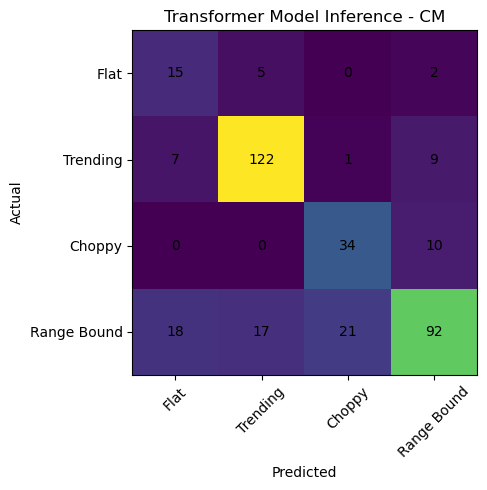

In [21]:
# visualize confusion matrix
cm = confusion_matrix(
    test_preds_df["true_regime_id"],
    test_preds_df["pred_regime_id"]
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Transformer Model Inference - CM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(target_names)), target_names, rotation=45)
plt.yticks(range(len(target_names)), target_names)

# annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [22]:
# add predictions to entries
entries_df = pd.read_csv("multiasset_labeled_entries_with_regime.csv")
entries_df["ts_entry"]     = pd.to_datetime(entries_df["ts_entry"], utc=True)
entries_df["session_date"] = (
    entries_df["ts_entry"].dt.tz_convert("America/New_York").dt.date.astype(str)
)
all_preds_df["session_date"] = all_preds_df["session_date"].astype(str)

prob_cols = ["pred_regime_id", "prob_flat", "prob_trending", "prob_choppy", "prob_range_bound"]
entries_with_preds = entries_df.merge(
    all_preds_df[["symbol", "session_date"] + prob_cols],
    on=["symbol", "session_date"],
    how="left"
)

print("Total entries:", len(entries_with_preds))
print("Missing pred_regime_id:", entries_with_preds["pred_regime_id"].isna().sum())
print("\nPredicted regime distribution:")
print(entries_with_preds["pred_regime_id"].map(REGIME_INT).value_counts())

entries_with_preds.to_csv("multiasset_labeled_entries_with_transformer_preds.csv", index=False)
print("\nSaved multiasset_labeled_entries_with_transformer_preds.csv")

Total entries: 1508
Missing pred_regime_id: 11

Predicted regime distribution:
pred_regime_id
Trending       508
Range Bound    486
Choppy         365
Flat           138
Name: count, dtype: int64

Saved multiasset_labeled_entries_with_transformer_preds.csv
